<a href="https://colab.research.google.com/github/pzedros/metodos_numericos/blob/main/Aula_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import math
import matplotlib.pyplot as plt
import pandas as pd



Eppara: 5e-07
   n  Estimativa         Ept         Epest
0  1    1.000000   70.018372  1.000000e+02
1  2    1.443682  145.452463  3.073267e+01
2  3    1.476491  151.030588  2.222090e+00
3  4    1.477461  151.195582  6.568357e-02
4  5    1.477477  151.198197  1.040797e-03
5  6    1.477477  151.198222  1.026184e-05
6  7    1.477477  151.198223  6.898477e-08


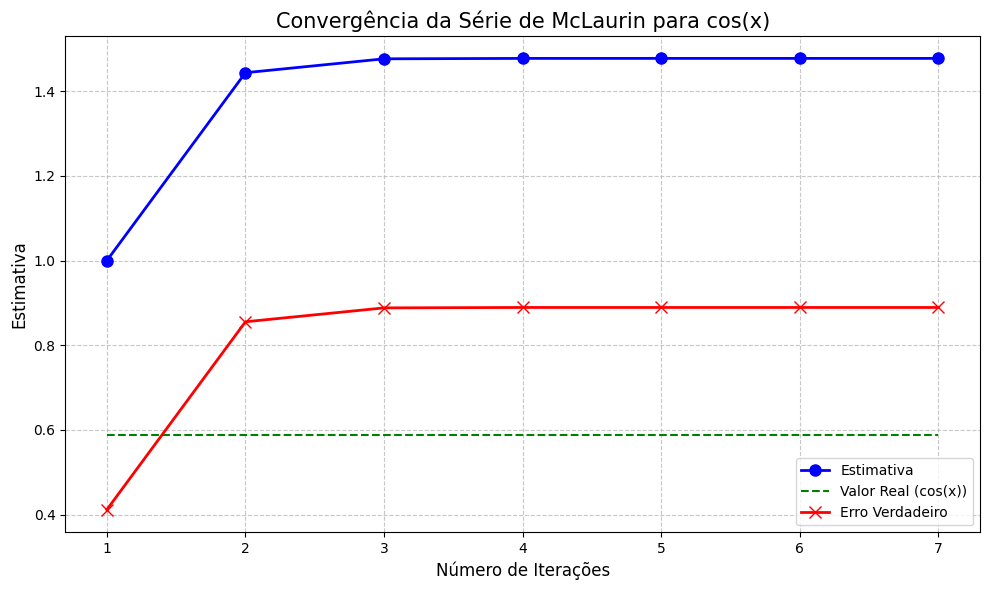

In [ ]:
#detrminar o numero de termos necessarios para aproximar cosx até 8 algarismos significativos usando a aproximação por serie de mclaurin

#definindo o valor de x
x =0.3*3.14

u = math.cos(x)
#definindo a função
def serie_mc_laurin(x,i):
  return(((1)**(i)))*(x**(2*i))/(math.factorial(2*i))



#criterio de scarvought(1966)
n=8
Eppara=0.5*10**(2-n)
print("Eppara:", Eppara)

#definindo variaveis
soma=0
v_old=soma
i=0
estimativa=[]
EPT=[]
Ept=100
Epest=100
EPEST=[]
nn=[]

while Epest >= Eppara:
  soma=soma+serie_mc_laurin(x,i)
  v_new=soma
  Ept=abs((u-soma)/u)*100
  Epest=abs((v_new -v_old)/v_new)*100

  i=i+1
  v_old=v_new

  #salvar os calculos
  nn.append(i)
  estimativa.append(soma)
  EPT.append(Ept)
  EPEST.append(Epest)

#DATA FRAME
table = pd.DataFrame()
table['n'] = nn
table['Estimativa'] = estimativa
table['Ept'] = EPT
table['Epest'] = EPEST
print(table)

# Calcula o erro verdadeiro
table['Et'] = abs(math.cos(x) - table['Estimativa'])

# Gráfico do Data Frame
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(table['n'], table['Estimativa'], 'o-', color='blue', label='Estimativa', markersize=8, linewidth=2)
ax.plot(table['n'], [math.cos(x)] * len(table['n']), '--', color='green', label='Valor Real (cos(x))')

# Plota o erro verdadeiro
ax.plot(table['n'], table['Et'], 'x-', color='red', label='Erro Verdadeiro', markersize=8, linewidth=2)

ax.set_xlabel('Número de Iterações', fontsize=12)
ax.set_ylabel('Estimativa', fontsize=12)
ax.set_title('Convergência da Série de McLaurin para cos(x)', fontsize=15)

ax.grid(True, linestyle='--', alpha=0.7)
ax.legend(fontsize=10, loc='best')

plt.tight_layout()
plt.show()


# Nova seção